In [2]:
# Raw Data Loading (연속형 데이터)
import numpy as np

raw_data = np.genfromtxt('./x09.txt', skip_header=36)

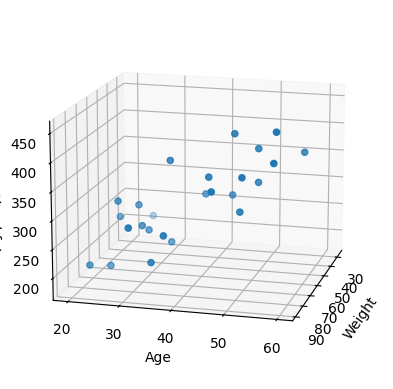

In [3]:
# Data Visualization
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

xs = np.array(raw_data[:, 2], dtype=np.float32)
ys = np.array(raw_data[:, 3], dtype=np.float32)
zs = np.array(raw_data[:, 4], dtype=np.float32)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs, ys, zs)
ax.set_xlabel('Weight')
ax.set_ylabel('Age')
ax.set_zlabel('Blood fat')
ax.view_init(elev=15, azim=15)
plt.show()

In [5]:
x_data = np.array(raw_data[:, 2:4], dtype=np.float32)
y_data = np.array(raw_data[:, 4], dtype=np.float32)
print(y_data.shape)

y_data = y_data.reshape((-1, 1))
print(y_data.shape)

(25,)
(25, 1)


In [12]:
# Model
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(2,))
])

model.compile(optimizer='rmsprop', loss='mse')

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_data, y_data, epochs=5000)

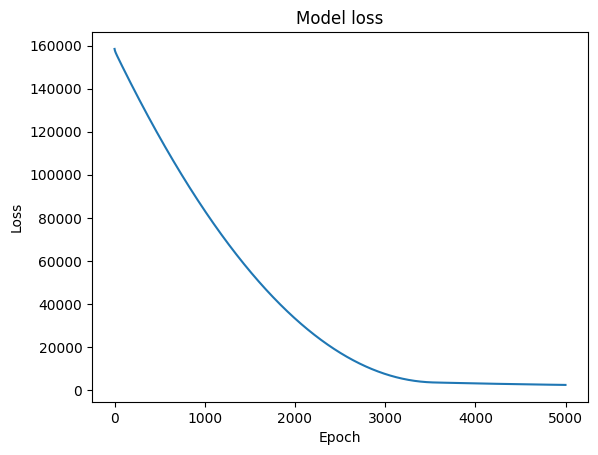

In [14]:
plt.plot(hist.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [15]:
# 예측
model.predict(np.array([[60, 25]], dtype=np.float32))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[234.6297]], dtype=float32)

In [16]:
w_, b_ = model.get_weights()
w_, b_

(array([[2.2606857],
        [3.7609236]], dtype=float32),
 array([4.965454], dtype=float32))

In [18]:
x = np.linspace(20, 100, 50).reshape((-1, 1))
y = np.linspace(10, 70, 50).reshape((-1, 1))

x = np.concatenate((x, y), axis=1)
Z = np.matmul(x, w_) + b_

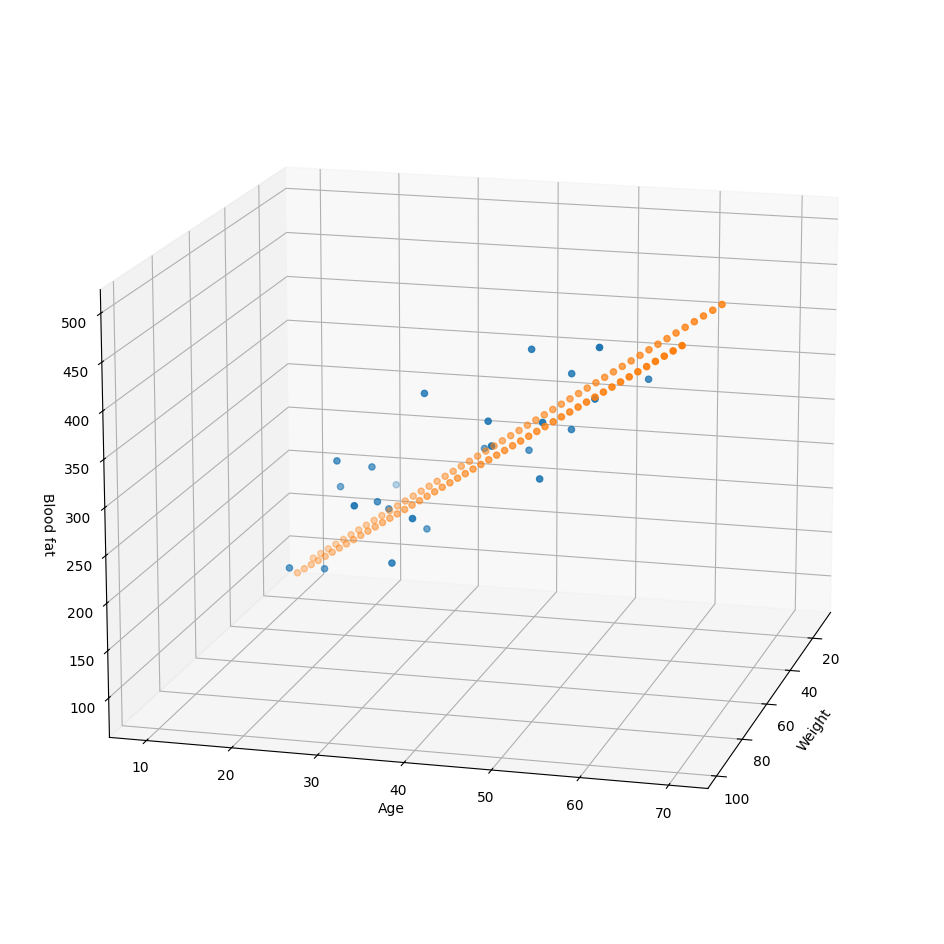

In [19]:
# 회귀선 시각화
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(xs, ys, zs)
ax.scatter(x, y, Z)
ax.set_xlabel('Weight')
ax.set_ylabel('Age')
ax.set_zlabel('Blood fat')
ax.view_init(elev=15, azim=15)
plt.show()

In [20]:
# XOR Gate 학습 (이진 데이터)

x = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0], [1], [1], [0]])

In [21]:
# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(2, input_shape=(2,), activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='mse', optimizer=tf.keras.optimizers.SGD(learning_rate=0.1))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x, y, epochs=5000, batch_size=1)

In [28]:
# 예측
model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0.04752835],
       [0.49731806],
       [0.9464282 ],
       [0.5036902 ]], dtype=float32)

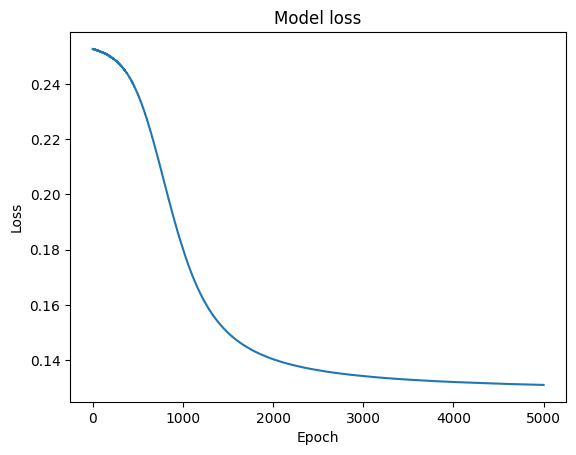

In [29]:
plt.plot(hist.history['loss'])

plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [30]:
# Raw Data Loading (범주형 데이터)
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

In [31]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [32]:
# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(y.reshape(-1, 1))

enc.categories_

[array([0, 1, 2])]

In [33]:
enc.transform(y.reshape(-1, 1)).toarray()[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [34]:
y_onehot = enc.transform(y.reshape(-1, 1)).toarray()

In [39]:
# Data Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y_onehot,
                                                    test_size=0.2,
                                                    random_state=13)

In [36]:
# Model
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, input_shape=(4,), activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,371 (9.26 KB)

 Trainable params: 2,371 (9.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test))

In [41]:
# 평가
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9667 - loss: 0.0831


[0.08309604972600937, 0.9666666388511658]

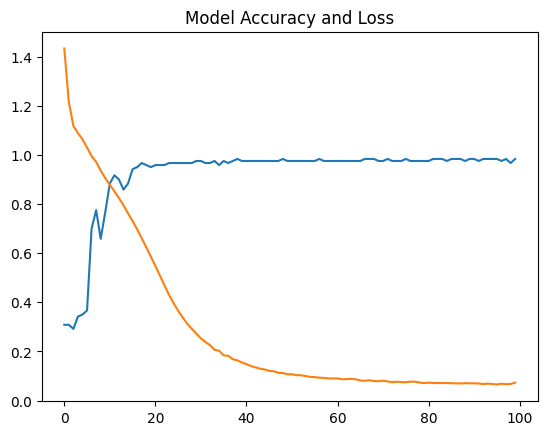

In [42]:
# Accuracy, Loss 시각화
plt.plot(hist.history['accuracy'], label='accuracy')
plt.plot(hist.history['loss'], label='loss')

plt.title('Model Accuracy and Loss')
plt.show()